# 01 — Exploración inicial (PySpark)

EDA con PySpark sobre los datos bronze (TLC ya adaptado al schema del PDF).

**Pre-requisito:** haber corrido al menos la tarea `ingest` del DAG.

**Nota técnica:** el SparkSession aquí usa `local[*]` (el motor corre dentro del contenedor Jupyter). El cluster externo `spark://mobility-spark-master` lo usa Airflow en el pipeline productivo; aquí queremos un entorno aislado para exploración sin depender de que los workers tengan montados los paths del notebook.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("mobility-exploration")
    .master("local[*]")
    .config("spark.driver.memory", "2g")
    .getOrCreate()
)
spark

In [2]:
BRONZE = "/home/jovyan/data/bronze/trips"
trips = spark.read.parquet(BRONZE)
trips.printSchema()
print("Filas:", trips.count())
trips.show(5, truncate=False)

root
 |-- trip_id: string (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance_km: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- driver_id: string (nullable = true)

Filas: 4322960
+----------------------------+-------------------+-------------------+----------------+---------------+-----------------+----------------+---------------+----------------+-----------+------------+---------+
|trip_id                     |pickup_datetime    |dropoff_datetime   |pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|trip_distance_km|fare_amount|payment_type|driver_id|
+---

## Inspección de calidad

In [3]:
key_cols = ["pickup_datetime", "dropoff_datetime", "trip_distance_km", "fare_amount", "passenger_count"]
nulls = trips.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in key_cols
])
nulls.show()

+---------------+----------------+----------------+-----------+---------------+
|pickup_datetime|dropoff_datetime|trip_distance_km|fare_amount|passenger_count|
+---------------+----------------+----------------+-----------+---------------+
|              0|               0|               0|          0|        1212946|
+---------------+----------------+----------------+-----------+---------------+



In [4]:
trips.describe(["trip_distance_km", "fare_amount", "passenger_count"]).show()

+-------+------------------+------------------+------------------+
|summary|  trip_distance_km|       fare_amount|   passenger_count|
+-------+------------------+------------------+------------------+
|  count|           4322960|           4322960|           3110014|
|   mean|12.035226229382303|   18.977997698337|1.2982697183999814|
| stddev|1117.2554441885125|157.78258677439493|0.7330375870517437|
|    min|               0.0|            -990.0|                 0|
|    max|    420460.0147226|         325478.05|                 9|
+-------+------------------+------------------+------------------+



## Distribución por hora del día

Text(0.5, 1.0, 'Demanda por hora (bronze)')

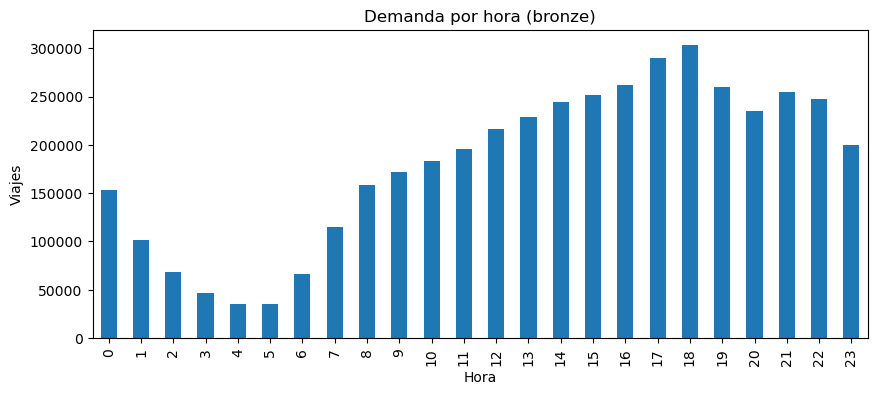

In [5]:
by_hour = (
    trips.withColumn("hour", F.hour("pickup_datetime"))
         .groupBy("hour").count()
         .orderBy("hour")
         .toPandas()
)
ax = by_hour.plot.bar(x="hour", y="count", legend=False, figsize=(10, 4))
ax.set_xlabel("Hora"); ax.set_ylabel("Viajes"); ax.set_title("Demanda por hora (bronze)")

## Outliers candidatos
Estos son los registros que `clean.py` descarta.

In [6]:
outliers = trips.filter(
    (F.col("trip_distance_km") <= 0)
    | (F.col("fare_amount") <= 0)
    | (F.col("passenger_count") <= 0)
)
print("Outliers:", outliers.count())
outliers.select("trip_distance_km", "fare_amount", "passenger_count").show(10)

Outliers: 408798
+------------------+-----------+---------------+
|  trip_distance_km|fare_amount|passenger_count|
+------------------+-----------+---------------+
|          2.655411|       -1.5|           NULL|
|13.228774800000002|       -1.5|           NULL|
|        11.1366328|       -1.5|           NULL|
|         4.3291246|      -4.75|           NULL|
|3.5566413999999997|      -4.75|           NULL|
|         2.7680648|      -4.75|           NULL|
|         5.3430088|      -4.75|           NULL|
|         3.0094658|      -4.75|           NULL|
|        11.8769292|       -1.5|           NULL|
|         2.6393176|       -1.5|           NULL|
+------------------+-----------+---------------+
only showing top 10 rows



In [7]:
spark.stop()